In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


1. Import Libraries

In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

2. Load Dataset

In [4]:
df = pd.read_csv("advertising.csv")

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:

df.describe()


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:

df.shape


(200, 4)

In [8]:

df.columns


Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

4. Check Missing Values

In [9]:

df.isnull().sum()


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

5. Check Duplicate Values

In [10]:

df.duplicated().sum()

np.int64(0)

6. Display Dataset

In [11]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


7.Correlation Matrix

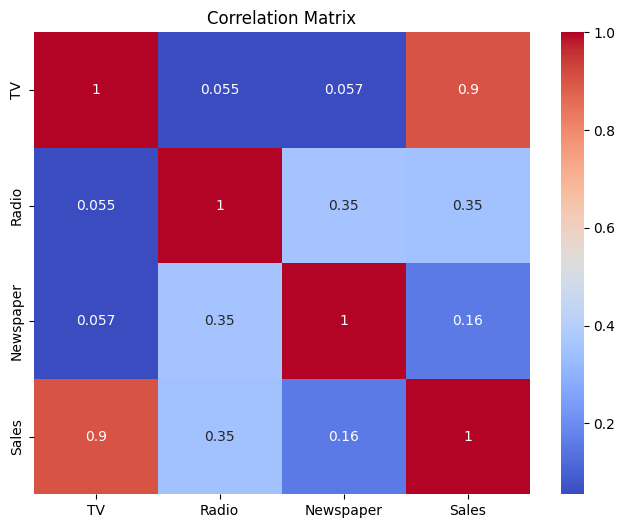

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

8.Pair Plot

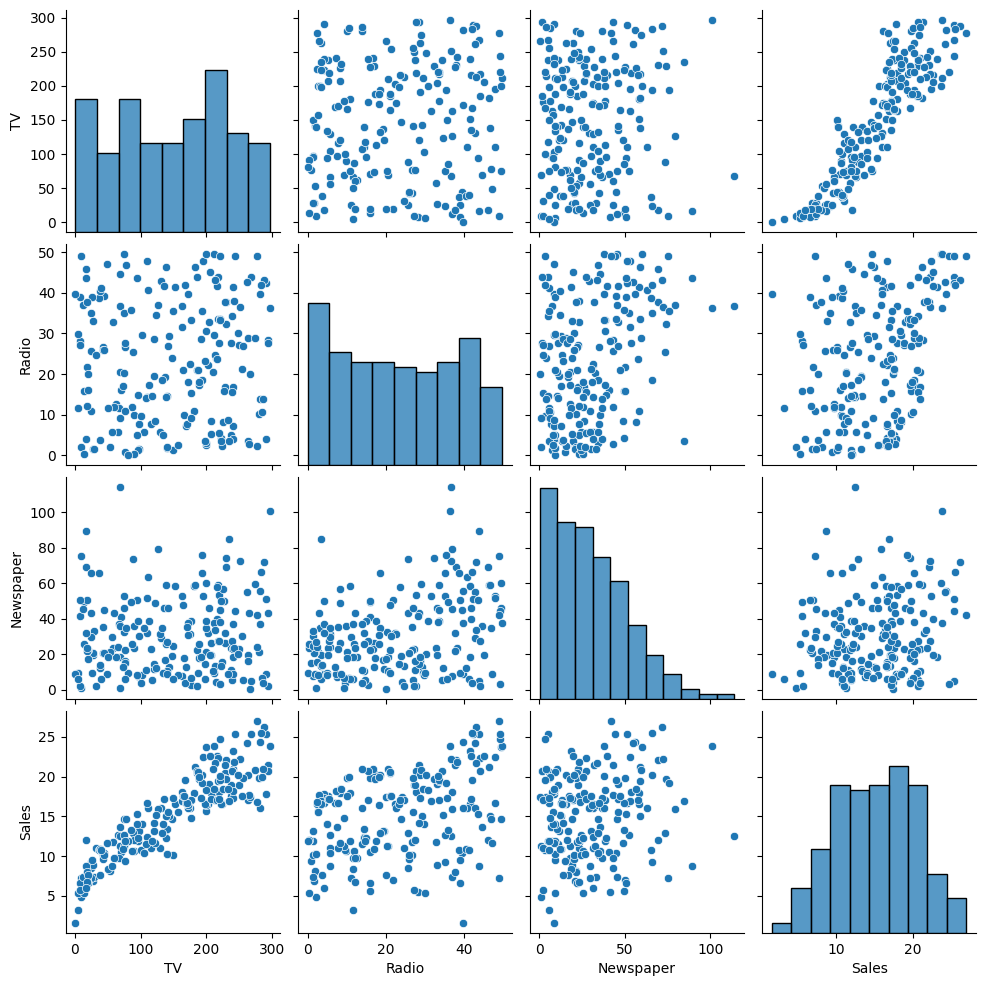

In [13]:
sns.pairplot(df)

plt.show()

9. Distribution of Sales

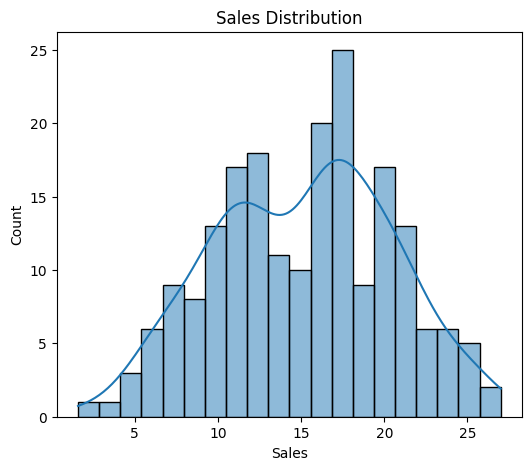

In [14]:
plt.figure(figsize=(6,5))

sns.histplot(df['Sales'],bins=20,kde=True)

plt.title("Sales Distribution")

plt.show()

10.TV vs Sales

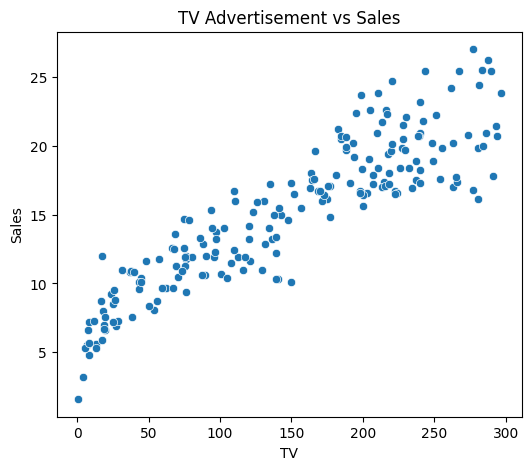

In [15]:
plt.figure(figsize=(6,5))

sns.scatterplot(x='TV',y='Sales',data=df)

plt.title("TV Advertisement vs Sales")

plt.show()

11.Radio vs Sales

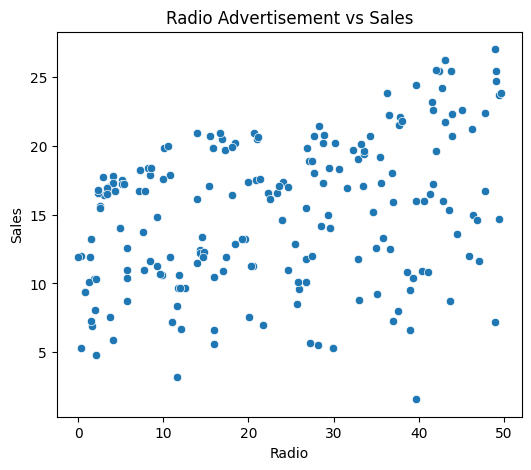

In [16]:
plt.figure(figsize=(6,5))

sns.scatterplot(x='Radio',y='Sales',data=df)

plt.title("Radio Advertisement vs Sales")

plt.show()

12.Newspaper vs Sales

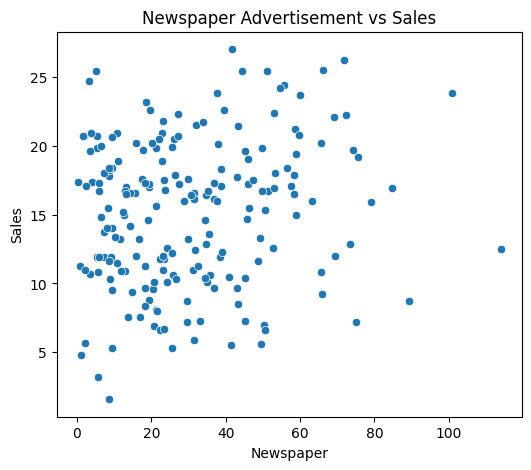

In [17]:
plt.figure(figsize=(6,5))

sns.scatterplot(x='Newspaper',y='Sales',data=df)

plt.title("Newspaper Advertisement vs Sales")

plt.show()

Define Features and Target

In [18]:
X = df[['TV','Radio','Newspaper']]

y = df['Sales']

Split Dataset

In [19]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [20]:
model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Model Coefficients

In [21]:
print("Intercept:",model.intercept_)

print()

coefficients = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coefficients

Intercept: 4.714126402214127



,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


Make Predictions

In [22]:
y_pred = model.predict(X_test)

Compare Actual and Predicted

In [23]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison.head(10)

,Actual,Predicted
95,16.9,17.034772
15,22.4,20.409740
30,21.4,23.723989
158,7.3,9.272785
128,24.7,21.682719
115,12.6,12.569402
69,22.3,21.081195
170,8.4,8.690350
174,16.5,17.237013
45,16.1,16.666575


Evalute Model

In [24]:
mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred)

print("Mean Absolute Error :",mae)

print("Mean Squared Error :",mse)

print("Root Mean Squared Error :",rmse)

print("R2 Score :",r2)

Mean Absolute Error : 1.2748262109549338
Mean Squared Error : 2.9077569102710896
Root Mean Squared Error : 1.7052146229349223
R2 Score : 0.9059011844150826


Actual vs Predicted Graph

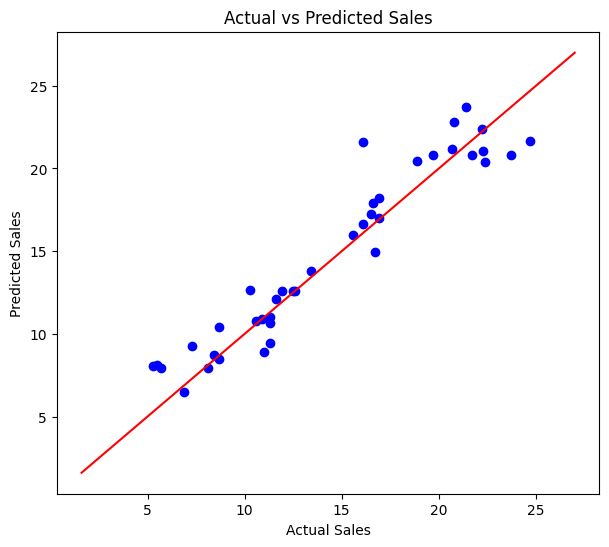

In [25]:
plt.figure(figsize=(7,6))

plt.scatter(y_test,y_pred,color='blue')

plt.plot(
    [y.min(),y.max()],
    [y.min(),y.max()],
    color='red'
)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

Residual Plot

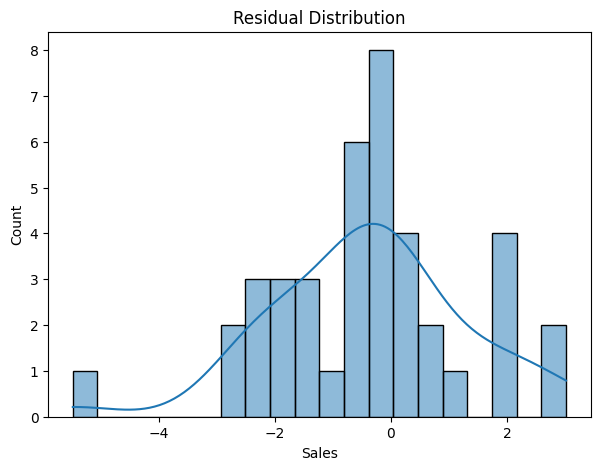

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

sns.histplot(residuals,bins=20,kde=True)

plt.title("Residual Distribution")

plt.show()

Predict New Sales

In [27]:
new_data = pd.DataFrame({
    "TV":[230],
    "Radio":[37.8],
    "Newspaper":[69.2]
})

prediction = model.predict(new_data)

print("Predicted Sales =",prediction[0])

Predicted Sales = 21.367089353313162


Conclusion

• Built a Sales Prediction model using Linear Regression.
• Performed data preprocessing and exploratory data analysis.
• Found that TV advertising has the strongest positive impact on Sales.
• Radio advertising also contributes significantly.
• Newspaper advertising has comparatively less influence.
• Evaluated the model using MAE, RMSE, and R² Score.
• The model can estimate future sales based on advertising expenditure.